### [Implementing Convolutional Neural Networks in TensorFlow](https://towardsdatascience.com/implementing-convolutional-neural-networks-in-tensorflow-bc1c4f00bd34/)

> Building a Convolutional Neural Network using [TensorFlow](https://www.tensorflow.org/)

In [1]:
!pip install -q tensorflow tensorflow-datasets keras

In [2]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt

# Setting seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# 'X' pattern
def generate_x_image():
    return np.array([
        [1, 0, 0, 0, 1],
        [0, 1, 0, 1, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 1, 0],
        [1, 0, 0, 0, 1]
    ])

def generate_not_x_image():
    # Ensuring not to generate an 'X' pattern
    while True:
        img = np.random.randint(2, size=(5, 5))
        if not np.array_equal(img, generate_x_image()):
            return img

In [4]:
# Create a dataset
num_samples = 1000
images = []
labels = []

for _ in range(num_samples):
    if np.random.rand() > 0.5:
        images.append(generate_x_image())
        labels.append(1)
    else:
        images.append(generate_not_x_image())
        labels.append(0)

images = np.array(images).reshape(-1, 5, 5, 1)
labels = np.array(labels)

In [5]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

In [6]:
print(f"Training dataset shape (x): {x_train.shape}")
print(f"Training dataset shape (y): {y_train.shape}")

Training dataset shape (x): (800, 5, 5, 1)
Training dataset shape (y): (800,)


In [7]:
print(f"Testing dataset shape (x): {x_test.shape}")
print(f"Testing dataset shape (y): {y_test.shape}")

Testing dataset shape (x): (200, 5, 5, 1)
Testing dataset shape (y): (200,)


In [8]:
# Function to display images
def display_sample_data(images, labels, num_samples=5):
    plt.figure(figsize=(10, 2))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].reshape(5, 5), cmap='gray_r')
        plt.title(f'Label: {labels[i]}')
        plt.axis('off')
    plt.show()

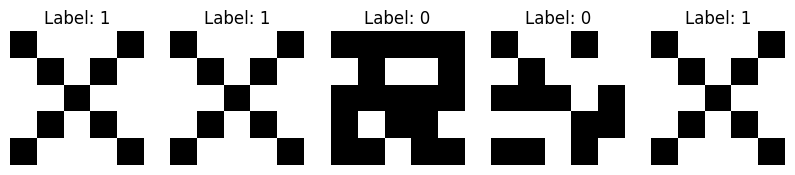

In [9]:
# Display first 5 samples of our training data
display_sample_data(x_train, y_train)

In [10]:
model = Sequential([
    # 1 - Convolutional Layer
    Conv2D(4, (3, 3), activation='relu', input_shape=(5, 5, 1)),
    # 2 - Max-Pooling Layer
    MaxPooling2D(pool_size=(2, 2)),
    # 3 - Flatten Layer
    Flatten(),
    # 4 - Hidden Layer
    Dense(3, activation='relu'),
    # 5 - Output Layer
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
model.compile(optimizer=Adam(), loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 3, 3, 4)        │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 4)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59 (236.00 B)

 Trainable params: 59 (236.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(x_train, y_train, epochs=10, validation_data=(x_test, y_test))

Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5436 - loss: 0.6806 - val_accuracy: 0.7650 - val_loss: 0.6617
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7452 - loss: 0.6612 - val_accuracy: 0.7400 - val_loss: 0.6440
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7574 - loss: 0.6436 - val_accuracy: 0.7500 - val_loss: 0.6248
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7652 - loss: 0.6248 - val_accuracy: 0.7500 - val_loss: 0.6038
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7984 - loss: 0.6038 - val_accuracy: 0.7850 - val_loss: 0.5802
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8218 - loss: 0.5799 - val_accuracy: 0.8150 - val_loss: 0.5538
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8504 - loss: 0.5528 - val_accuracy: 0.8500 - val_loss: 0.5241
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8688 - loss: 0.5227 - val_accuracy: 0.8750 - val_loss

In [14]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Accuracy: {accuracy * 100:.2f}%')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9115 - loss: 0.4412 
Test Accuracy: 93.50%


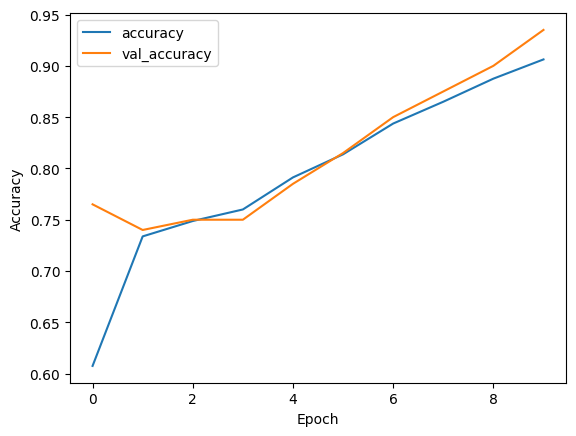

In [15]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()